# Neutron reflectometry  (Normalizing Flow inference)

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from reflectorch import EasyInferenceModel, interp_reflectivity

torch.manual_seed(0); # set seed for reproducibility

# Reproducing first example (Ni500.dat)

We consider the following NR data for a 1-layer stucture of Ni on Si (air as ambient), measured at a resolution dq/q = 0.1 (i.e. 10%):

In [2]:
data = np.loadtxt('../exp_data/Ni500.dat', delimiter='\t', skiprows=0)
print(data.shape)

q_exp = data[..., 0]
curve_exp = data[..., 1]
sigmas_exp = data[..., 2]

print(curve_exp.shape, q_exp.shape, q_exp.min(), q_exp.max())
print(sigmas_exp.shape, sigmas_exp.max(), sigmas_exp.min(), (sigmas_exp / curve_exp).max())

(174, 3)
(174,) (174,) 0.01333 0.22399
(174,) 8.83715e-05 4.23214e-07 0.3282606076124776


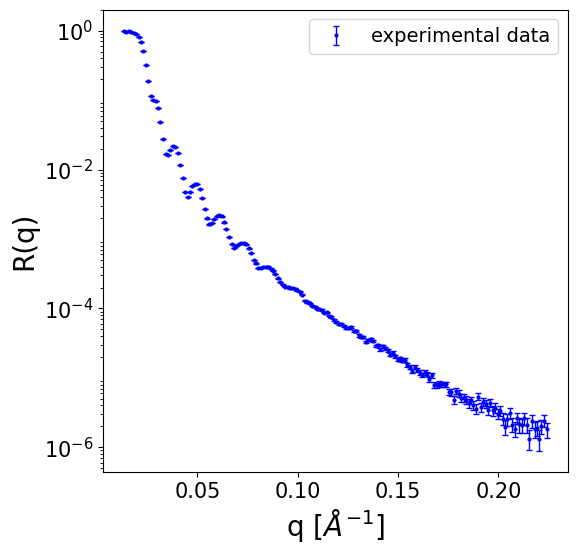

In [3]:
fig, ax = plt.subplots(1,1,figsize=(6,6))

ax.set_yscale('log')
ax.set_xlabel('q [$Å^{-1}$]', fontsize=20)
ax.set_ylabel('R(q)', fontsize=20)

ax.tick_params(axis='both', which='major', labelsize=15)
ax.tick_params(axis='both', which='minor', labelsize=15)

y_tick_locations = [10**(-2*i) for i in range(6)]
ax.yaxis.set_major_locator(plt.FixedLocator(y_tick_locations))

el = ax.errorbar(q_exp, curve_exp, fmt='o', markersize=2, linewidth=1,zorder=2,
                 yerr=sigmas_exp, xerr=None, color='blue', ecolor='blue', elinewidth=1, capsize=2, barsabove=False,
                 label='experimental data')
elines = el.get_children()
elines[1].set_color('green')

ax.legend(loc='upper right', fontsize=14)

We initialize an inference object for a model trained for neutron reflectometry and a standard parameterization with 1 layer (for more details on the `EasyInferenceModel` class see the previous tutorial):

In [4]:
config_name = 'example_nf_config_reflectorch.yaml'

inference_model = EasyInferenceModel(config_name=config_name,
                                     device='cpu',
                                     )

Configuration file `/home/levytskyi/Documents/reflectorch_devvm/reflectorch/configs/example_nf_config_reflectorch.yaml` found locally.
Weights file `/home/levytskyi/Documents/reflectorch_devvm/reflectorch/saved_models/model_example_nf_config_reflectorch.safetensors` found locally.
Model example_nf_config_reflectorch.yaml loaded. Number of parameters: 40.91 M
The model corresponds to a `standard_model` parameterization with 1 layers (7 predicted parameters)
Parameter types and total ranges:
- thicknesses: [1.0, 1500.0]
- roughnesses: [0.0, 60.0]
- slds: [-8.0, 16.0]
- r_scale: [0.9, 1.1]
- log10_background: [-10.0, -4.0]
Allowed widths of the prior bound intervals (max-min):
- thicknesses: [0.01, 1500.0]
- roughnesses: [0.01, 60.0]
- slds: [0.01, 24.0]
- r_scale: [0.001, 0.2]
- log10_background: [0.01, 6.0]
The model was trained on curves discretized at exactly 256 uniform points, between q_min in [0.001, 0.02] and q_max in [0.05, 0.4]
The model was trained with linear resolution smeari

We interpolate the data to a discretization suitable for this model:

In [5]:
q_model, exp_curve_interp = inference_model.interpolate_data_to_model_q(q_exp, curve_exp)

print(q_model.shape, q_model.min(), q_model.max())
print(exp_curve_interp.shape)

(256,) 0.01333 0.22399
(256,)


We set some prior bounds for the parameters:

In [6]:
# adding parameters from training: r_scale: [0.9, 1.1], log10_background: [-10.0, -4.0]

prior_bounds = [(300., 900.), #layer thicknesses (top to bottom)
                (0., 20.), (0., 20.), #interlayer roughnesses (top to bottom)
                (9., 11.), (3., 5.), #real layer slds: Ni, glass
                (0.9, 1.1), (-10.0, -4.0)] 

For performing the prediction we need to provide the `q_resolution` argument. When this argument is a *float*, its meaning is dq/q. This value is always used for simulating the reflectivity curve corresponding to the predicted parameters and as a keyword argument to the reflectivity function during polishing. Depending on the training scenario, it might also be used as an additional input to the network.

# Performing inference

In [7]:
prediction_dict = inference_model.preprocess_and_sample(reflectivity_curve=exp_curve_interp,q_values=q_model, num_samples=1000, prior_bounds=prior_bounds, q_resolution=0.1, calc_sampled_curves=True, calc_sampled_sld_profiles=True)

/home/levytskyi/Documents/reflectorch_devvm/reflectorch/nfref/lib/python3.12/site-packages/nflows/transforms/coupling.py:481: UserWarning: Inputs to the softmax are not scaled down: initialization might be bad.
  warnings.warn(


In [8]:
prediction_dict.keys()

dict_keys(['predicted_params_object', 'predicted_params_array', 'param_names', 'sampled_curves', 'q_plot_pred', 'sampled_sld_profiles', 'sampled_sld_xaxis', 'q_model', 'reflectivity_curve_interp', 'q_resolution_interp'])

# Defining initial postprocessing function

In [9]:
def postprocess(prediction_dict):
    # Extract data
    sampled_curves = prediction_dict['sampled_curves']
    sampled_slds = prediction_dict['sampled_sld_profiles']
    sld_xaxis = prediction_dict['sampled_sld_xaxis']
    q_plot = prediction_dict['q_plot_pred']

    # Extract missing variables
    pred_params = prediction_dict['predicted_params_array']
    param_names = prediction_dict['param_names']

    # 1. Calculate and print Mean + Std Dev
    mean_params = np.mean(pred_params, axis=0)
    std_params = np.std(pred_params, axis=0)

    print(f"{'Parameter':<20} | {'Mean':<12} | {'Std Dev':<12}")
    print("-" * 50)
    for name, mean, std in zip(param_names, mean_params, std_params):
        print(f"{name:<20} | {mean:<12.4f} | {std:<12.4f}")


    # 2. Plotting
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    # --- Left Plot: Reflectivity ---
    ax[0].set_yscale('log')
    ax[0].set_xlabel('q [$Å^{-1}$]', fontsize=14)
    ax[0].set_ylabel('R(q)', fontsize=14)
    ax[0].set_title('Reflectivity', fontsize=16)

    # Plot experimental data
    ax[0].errorbar(q_exp, curve_exp, yerr=sigmas_exp, fmt='o', color='black', 
                markersize=3, alpha=0.6, label='Exp. Data', zorder=10)

    # Plot sampled curves
    for i, curve in enumerate(sampled_curves):
        label = "Predicted Samples" if i == 0 else None
        ax[0].plot(q_plot, curve, color='red', alpha=0.3, linewidth=1, label=label)

    ax[0].legend(fontsize=12)
    ax[0].grid(alpha=0.2, which='both')

    # --- Right Plot: SLD Profile ---
    ax[1].set_xlabel('z [$Å$]', fontsize=14)
    ax[1].set_ylabel('SLD [$10^{-6} Å^{-2}$]', fontsize=14)
    ax[1].set_title('SLD Profile', fontsize=16)

    # Plot sampled SLD profiles
    for i, sld in enumerate(sampled_slds):
        label = "Predicted Samples" if i == 0 else None
        ax[1].plot(sld_xaxis, sld, color='red', alpha=0.3, linewidth=1, label=label)

    ax[1].legend(fontsize=12)
    ax[1].grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

# Inference results

Parameter            | Mean         | Std Dev     
--------------------------------------------------
Thickness L1         | 498.6695     | 5.3152      
Roughness L1         | 6.5496       | 0.8182      
Roughness sub        | 6.0919       | 0.8815      
SLD L1               | 10.0235      | 0.5964      
SLD sub              | 2.6319       | 3.7726      
r_scale              | -0.3209      | 4.3392      
log10_background     | -6.6743      | 0.4880      


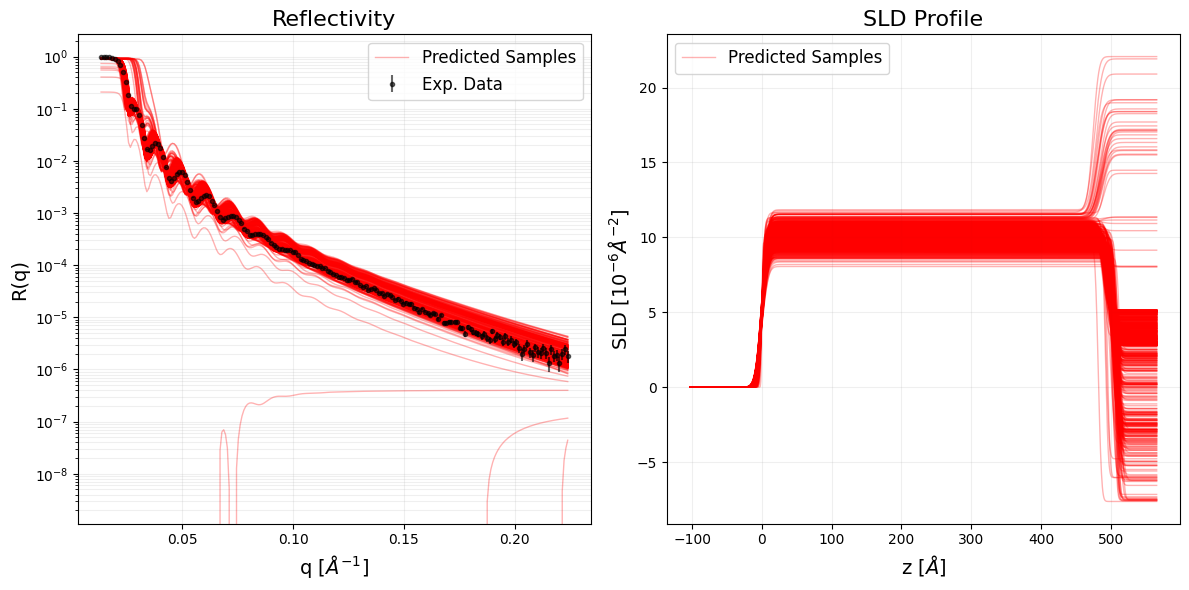

In [10]:
postprocess(prediction_dict)

In [11]:
# Previous reflectorch results:

# Thickness L1   -> Predicted: 498.53       Polished: 497.37
# Roughness L1   -> Predicted: 6.45       Polished: 5.65
# Roughness sub  -> Predicted: 7.68       Polished: 9.39
# SLD L1         -> Predicted: 10.24       Polished: 10.24
# SLD sub        -> Predicted: 3.92       Polished: 3.87

# Testing on the second example (Ni on glass)

In [12]:
data = np.loadtxt('../exp_data/Ni_on_glass.dat', delimiter='\t', skiprows=0)
print(data.shape)

q_exp = data[..., 0]
curve_exp = data[..., 1]

print(curve_exp.shape, q_exp.shape, q_exp.min(), q_exp.max())


(757, 2)
(757,) (757,) 0.00508981 0.175655


In [13]:
# inference model stays the same

In [14]:
prior_bounds = [
    (300., 900.), #layer thicknesses (top to bottom)
    (0., 20.), (0., 20.), #interlayer roughnesses (top to bottom)
    (9., 11.), (3., 5.), #layer slds: Ni, glass
    (0.9, 1.1), #intensity scaling factor
    (-10, -4), #log10 background
] 

In [15]:
q_model, exp_curve_interp = inference_model.interpolate_data_to_model_q(q_exp, curve_exp)

print(q_model.shape, q_model.min(), q_model.max())
print(exp_curve_interp.shape)

(256,) 0.00508981 0.175655
(256,)


## Inference

In [16]:
prediction_dict = inference_model.preprocess_and_sample(
    reflectivity_curve=exp_curve_interp,
    q_values=q_model, 
    num_samples=1000, 
    prior_bounds=prior_bounds, 
    q_resolution=0.015, # was 0.1 in the previous example
    calc_sampled_curves=True, 
    calc_sampled_sld_profiles=True)

## Adjusted postprocess function (error bars removed)

In [17]:
def postprocess(prediction_dict):
    # Extract data
    sampled_curves = prediction_dict['sampled_curves']
    sampled_slds = prediction_dict['sampled_sld_profiles']
    sld_xaxis = prediction_dict['sampled_sld_xaxis']
    q_plot = prediction_dict['q_plot_pred']

    # Extract missing variables
    pred_params = prediction_dict['predicted_params_array']
    param_names = prediction_dict['param_names']

    # 1. Calculate and print Mean + Std Dev
    mean_params = np.mean(pred_params, axis=0)
    std_params = np.std(pred_params, axis=0)

    print(f"{'Parameter':<20} | {'Mean':<12} | {'Std Dev':<12}")
    print("-" * 50)
    for name, mean, std in zip(param_names, mean_params, std_params):
        print(f"{name:<20} | {mean:<12.4f} | {std:<12.4f}")


    # 2. Plotting
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    # --- Left Plot: Reflectivity ---
    ax[0].set_yscale('log')
    ax[0].set_xlabel('q [$Å^{-1}$]', fontsize=14)
    ax[0].set_ylabel('R(q)', fontsize=14)
    ax[0].set_title('Reflectivity', fontsize=16)

    # Plot experimental data
    ax[0].errorbar(q_exp, curve_exp, fmt='o', color='black', 
                markersize=3, alpha=0.6, label='Exp. Data', zorder=10)

    # Plot sampled curves
    for i, curve in enumerate(sampled_curves):
        label = "Predicted Samples" if i == 0 else None
        ax[0].plot(q_plot, curve, color='red', alpha=0.3, linewidth=1, label=label)

    ax[0].legend(fontsize=12)
    ax[0].grid(alpha=0.2, which='both')

    # --- Right Plot: SLD Profile ---
    ax[1].set_xlabel('z [$Å$]', fontsize=14)
    ax[1].set_ylabel('SLD [$10^{-6} Å^{-2}$]', fontsize=14)
    ax[1].set_title('SLD Profile', fontsize=16)

    # Plot sampled SLD profiles
    for i, sld in enumerate(sampled_slds):
        label = "Predicted Samples" if i == 0 else None
        ax[1].plot(sld_xaxis, sld, color='red', alpha=0.3, linewidth=1, label=label)

    ax[1].legend(fontsize=12)
    ax[1].grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

## Inference results

Parameter            | Mean         | Std Dev     
--------------------------------------------------
Thickness L1         | 817.8334     | 5.7555      
Roughness L1         | 11.7471      | 1.2960      
Roughness sub        | -22.5108     | 38.5397     
SLD L1               | 9.9792       | 0.5655      
SLD sub              | 4.8596       | 1.5090      
r_scale              | 0.9882       | 0.0101      
log10_background     | -4.0798      | 0.0718      


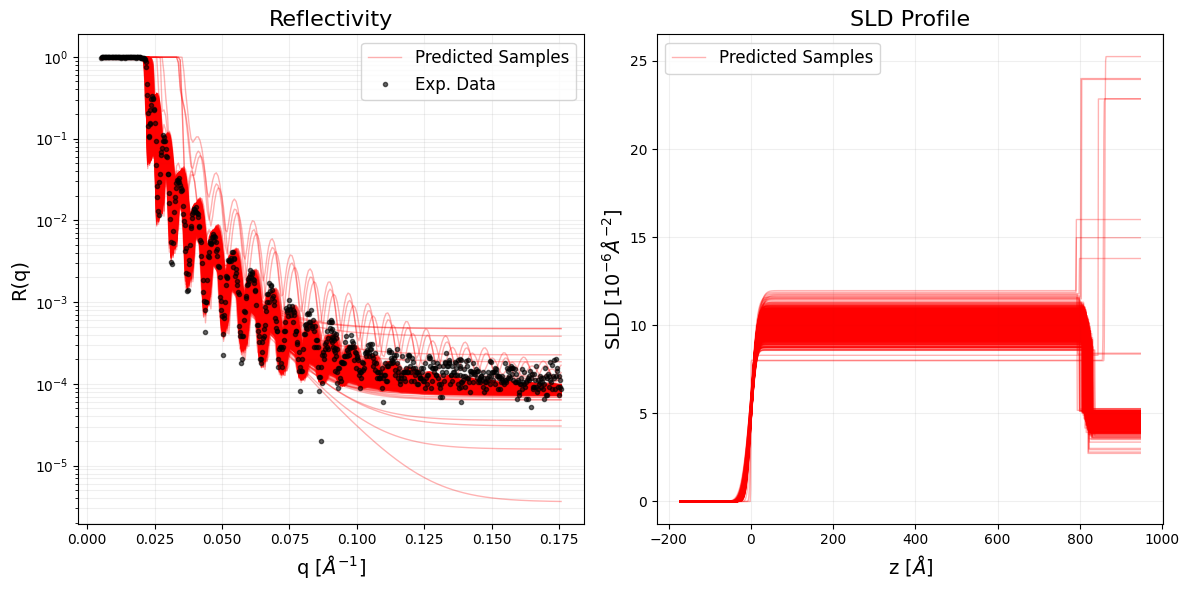

In [18]:
postprocess(prediction_dict)

In [19]:
# # from previous reflectorch results:
# Thickness L1   -> Predicted: 812.66       Polished: 826.98
# Roughness L1   -> Predicted: 8.42       Polished: 8.14
# Roughness sub  -> Predicted: 1.35       Polished: 0.00
# SLD L1         -> Predicted: 9.05       Polished: 9.17
# SLD sub        -> Predicted: 3.85       Polished: 4.00
# r_scale        -> Predicted: 0.97       Polished: 0.91
# log10_background -> Predicted: -4.17       Polished: -4.00

## Inference with likelihoods and importance sampling

In [20]:
prediction_dict = inference_model.preprocess_and_sample(
    reflectivity_curve=exp_curve_interp,
    q_values=q_model, 
    num_samples=10000, 
    prior_bounds=prior_bounds, 
    q_resolution=0.015, # was 0.1 in the previous example
    calc_sampled_curves=True, 
    calc_sampled_sld_profiles=True,
    calc_log_likelihoods=True,
    enable_importance_sampling=True)

Index of best sample: 831  Index of worst sample: 1519
Effective sample size: 1.5
Sample efficiency: 0.01 %


In [21]:
prediction_dict

{'predicted_params_object': BasicParams(batch_size=10000, max_layer_num=1, device=cpu),
 'predicted_params_array': array([[ 817.1128287 ,   13.16000026, -217.22990649, ...,    4.05209864,
            0.99102933,   -3.74359512],
        [ 819.14558556,   12.70702763,   -9.47738591, ...,    4.41771453,
            0.99238067,   -4.095438  ],
        [ 804.94997606,   14.73288329,  -50.98351652, ...,    5.03950358,
            0.99205678,   -4.12940407],
        ...,
        [ 811.9316948 ,   11.77072097,  -15.11356025, ...,    5.04608775,
            0.99316785,   -4.10377789],
        [ 820.54523379,    9.74202754,   -1.41320339, ...,    4.54098887,
            0.96650805,   -4.06475353],
        [ 815.7128586 ,   10.75290616,   -5.46735612, ...,    4.28227321,
            0.95173688,   -4.08953857]], shape=(10000, 7)),
 'param_names': ['Thickness L1',
  'Roughness L1',
  'Roughness sub',
  'SLD L1',
  'SLD sub',
  'r_scale',
  'log10_background'],
 'sampled_curves': array([[9.91166612e

Best Sample Index: 831 (LogL: -359.5069)
Worst Sample Index: 1519 (LogL: -1919083.7956)

Parameter Comparison:
Parameter            | Best Case    | Worst Case  
--------------------------------------------------
Thickness L1         | 824.5156     | 854.2511    
Roughness L1         | 10.9255      | 3.5750      
Roughness sub        | -1.4178      | 1.0663      
SLD L1               | 9.1055       | 8.0360      
SLD sub              | 4.0248       | 25.1162     
r_scale              | 0.9818       | 0.9805      
log10_background     | -4.0670      | -4.0320     


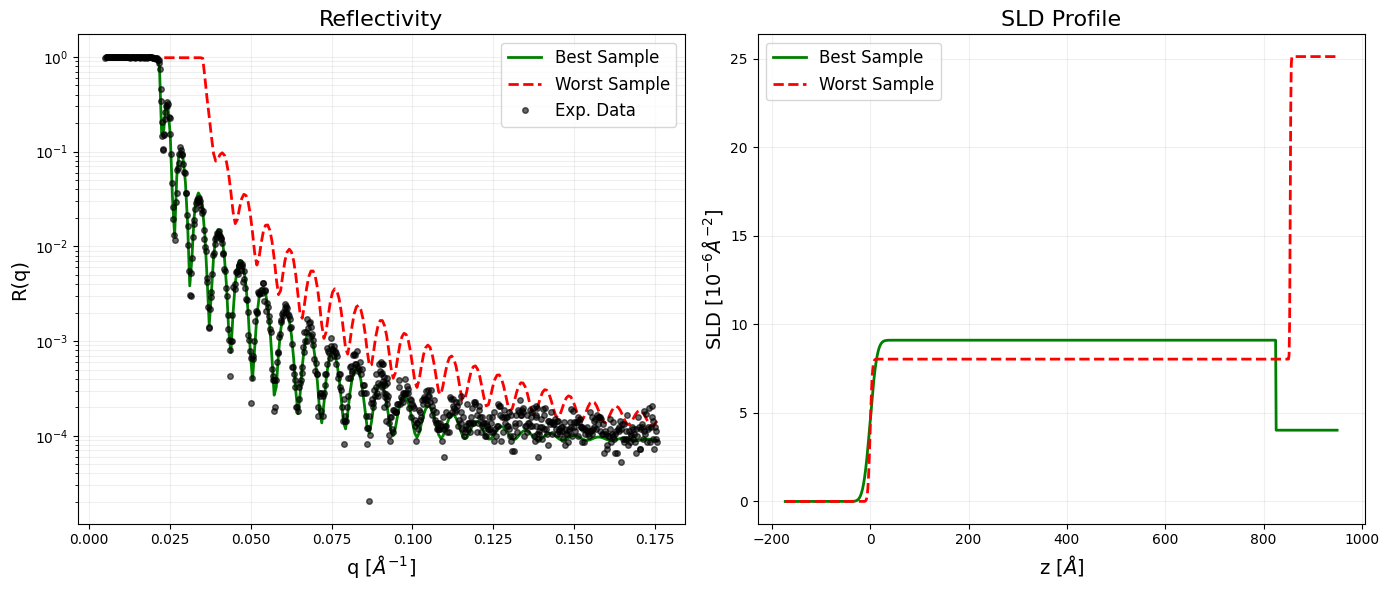

In [22]:
# ...existing code...
def postprocess_extremes(prediction_dict, best_idx=None, worst_idx=None):
    # Extract data
    log_likelihoods = prediction_dict.get('log_likelihoods')
    pred_params = prediction_dict['predicted_params_array']
    param_names = prediction_dict['param_names']
    
    sampled_curves = prediction_dict['sampled_curves']
    sampled_slds = prediction_dict['sampled_sld_profiles']
    
    q_plot = prediction_dict['q_plot_pred']
    sld_xaxis = prediction_dict['sampled_sld_xaxis']

    # Determine indices if not provided
    if log_likelihoods is not None:
        if best_idx is None:
            best_idx = np.argmax(log_likelihoods)
        if worst_idx is None:
            worst_idx = np.argmin(log_likelihoods)
        
        print(f"Best Sample Index: {best_idx} (LogL: {log_likelihoods[best_idx]:.4f})")
        print(f"Worst Sample Index: {worst_idx} (LogL: {log_likelihoods[worst_idx]:.4f})")
    else:
        print("Warning: 'log_likelihoods' not found. Using first and last samples.")
        best_idx = 0
        worst_idx = -1

    # 1. Print Parameters
    print("\nParameter Comparison:")
    print(f"{'Parameter':<20} | {'Best Case':<12} | {'Worst Case':<12}")
    print("-" * 50)
    for i, name in enumerate(param_names):
        val_best = pred_params[best_idx, i]
        val_worst = pred_params[worst_idx, i]
        print(f"{name:<20} | {val_best:<12.4f} | {val_worst:<12.4f}")

    # 2. Plotting
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))

    # --- Left Plot: Reflectivity ---
    ax[0].set_yscale('log')
    ax[0].set_xlabel('q [$Å^{-1}$]', fontsize=14)
    ax[0].set_ylabel('R(q)', fontsize=14)
    ax[0].set_title('Reflectivity', fontsize=16)

    # Plot Experimental Data (Ground Truth)
    ax[0].errorbar(q_exp, curve_exp, fmt='o', color='black', 
                markersize=4, alpha=0.6, label='Exp. Data', zorder=10)

    # Plot Best and Worst curves
    ax[0].plot(q_plot, sampled_curves[best_idx], color='green', linewidth=2, label='Best Sample')
    ax[0].plot(q_plot, sampled_curves[worst_idx], color='red', linestyle='--', linewidth=2, label='Worst Sample')

    ax[0].legend(fontsize=12)
    ax[0].grid(alpha=0.2, which='both')

    # --- Right Plot: SLD Profile ---
    ax[1].set_xlabel('z [$Å$]', fontsize=14)
    ax[1].set_ylabel('SLD [$10^{-6} Å^{-2}$]', fontsize=14)
    ax[1].set_title('SLD Profile', fontsize=16)

    # Plot Best and Worst SLDs
    ax[1].plot(sld_xaxis, sampled_slds[best_idx], color='green', linewidth=2, label='Best Sample')
    ax[1].plot(sld_xaxis, sampled_slds[worst_idx], color='red', linestyle='--', linewidth=2, label='Worst Sample')

    ax[1].legend(fontsize=12)
    ax[1].grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

# Run the function
postprocess_extremes(prediction_dict)

# Testing on Alexandros' data

In [23]:
data = np.loadtxt('../exp_data/s000004_experimental_curve.dat', skiprows=1)
print(data.shape)

q_exp = data[..., 0]
curve_exp = data[..., 1]
sigmas_exp = data[..., 2]
q_res_exp = data[..., 3]

print(curve_exp.shape, q_exp.shape, q_exp.min(), q_exp.max())
print(sigmas_exp.shape, sigmas_exp.max(), sigmas_exp.min(), (sigmas_exp / curve_exp).max())
print(q_res_exp.shape, (q_res_exp / q_exp).min(), (q_res_exp / q_exp).max())

(76, 4)
(76,) (76,) 0.0070072 0.283544
(76,) 0.0154092 1.01647e-06 24.521023810098182
(76,) 0.09999999999999998 0.10000000000000002


In [24]:
#layer        sld(A^-2)   thickness(A) roughness(A)  
# fronting      3.50000e-06      inf      8.04
# layer1        3.56709e-06      28.63      7.04
# backing       9.79867e-06      inf       none

prior_bounds = [
    (10., 50.), #layer thicknesses (top to bottom)
    (0., 15.), (0., 15.), #interlayer roughnesses (top to bottom)
    (3.0, 4.0), (9.0, 11.0), #layer slds: L1, Backing
    (0.9, 1.1), #intensity scaling factor
    (-10, -4), #log10 background
] 

In [25]:
q_model, exp_curve_interp = inference_model.interpolate_data_to_model_q(q_exp, curve_exp)

print(q_model.shape, q_model.min(), q_model.max())
print(exp_curve_interp.shape)

(256,) 0.0070072 0.283544
(256,)


In [26]:
q_res_interp = np.interp(q_model, q_exp, q_res_exp) #pointwise resolution smearing
print(q_res_exp.shape, q_res_interp.shape, q_res_exp.shape, (q_res_interp / q_model).min(), (q_res_interp / q_model).max())

(76,) (256,) (76,) 0.09999999999999998 0.10000000000000002


In [27]:
prediction_dict = inference_model.preprocess_and_sample(
    reflectivity_curve=exp_curve_interp,
    q_values=q_model,
    q_resolution=q_res_interp,
    num_samples=1000, #system crashes with 10.000 
    prior_bounds=prior_bounds, 
    calc_sampled_curves=True, 
    calc_sampled_sld_profiles=True,
    calc_log_likelihoods=True,
    enable_importance_sampling=True)

Index of best sample: 803  Index of worst sample: 892
Effective sample size: 1.0
Sample efficiency: 0.10 %


Best Sample Index: 803 (LogL: -683.7490)
Worst Sample Index: 892 (LogL: -36144.4677)

Parameter Comparison:
Parameter            | Best Case    | Worst Case  
--------------------------------------------------
Thickness L1         | 89.2326      | 52.5445     
Roughness L1         | 3.9062       | 6.1076      
Roughness sub        | -0.5833      | -0.9829     
SLD L1               | 4.1222       | 4.3213      
SLD sub              | 3.1755       | -1.8790     
r_scale              | 0.9728       | 0.9793      
log10_background     | -8.3077      | -8.8019     


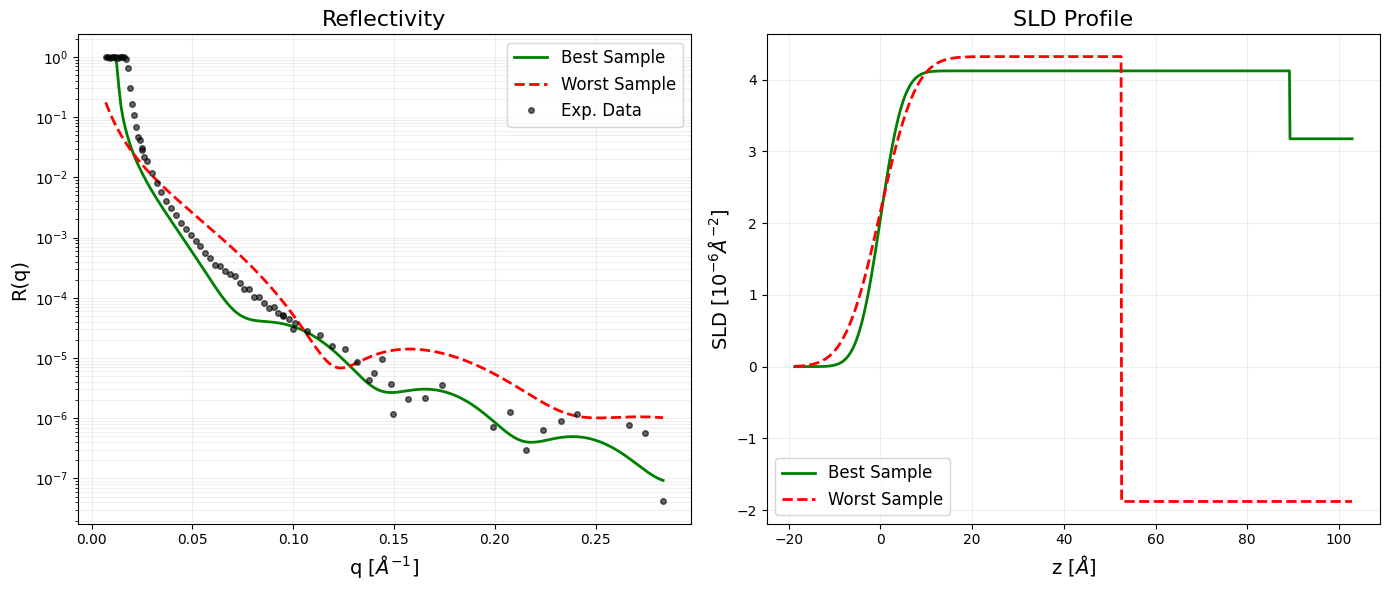

In [28]:
postprocess_extremes(prediction_dict)